# MESH formulation comparison

This notebook compares the four MESH (Maximum Expected Size of Hail)
calibrations supported by pyhail as a function of the Severe Hail Index (SHI).

| Calibration | Formula | Fitted to |
|-------------|---------|----------|
| `witt1998` | MESH = 2.54 × SHI^0.5 | 147 reports (Witt et al. 1998) |
| `mh2019_75` | MESH = 15.096 × SHI^0.206 | 5897 reports, 75th pct (Murillo & Homeyer 2021) |
| `mh2019_95` | MESH = 22.157 × SHI^0.212 | 5897 reports, 95th pct (Murillo & Homeyer 2021) |
| `blend` | Logistic blend of Witt (1998) and MH2019 75th pct | — |

The **blend** formulation uses a logistic weight to transition smoothly from the
Witt (1998) calibration at low SHI to the Murillo & Homeyer (2021) 75th-percentile
calibration at high SHI, removing the discontinuous derivative that arises from a
hard piecewise switch. The crossover point (SHI* ≈ 429 J m⁻¹ s⁻¹, MESH* ≈ 52.6 mm)
is the analytical intercept of the two power laws.

**SHI** (J m⁻¹ s⁻¹) is the column-integrated kinetic energy flux of hailstones,
computed from the radar reflectivity profile between the freezing level and the
-20 °C isotherm. A higher SHI indicates more intense hail-producing updrafts.

References:
- Witt et al. (1998) doi:10.1175/1520-0434(1998)013<0286:AEHDAF>2.0.CO;2
- Murillo & Homeyer (2021) doi:10.1175/JAMC-D-20-0271.1


In [1]:
from matplotlib import pyplot as plt
import numpy as np
from pyhail.mesh_formulas import mesh_smooth_blend


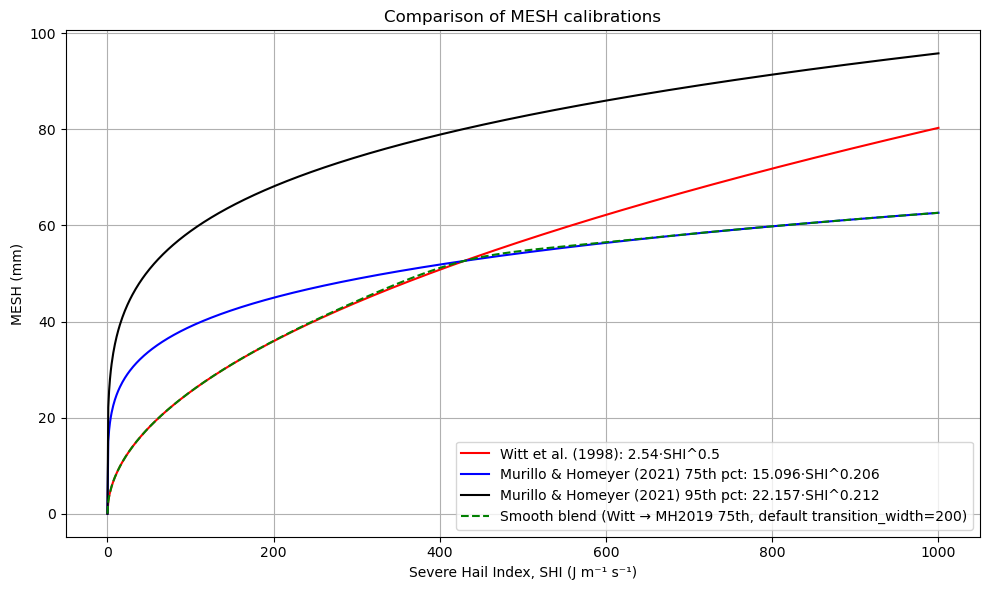

In [2]:
# SHI range over which to evaluate the calibrations
shi = np.arange(0, 1001)  # J m^-1 s^-1

# Four MESH calibrations
mesh_witt      = 2.54   * shi ** 0.5    # Witt et al. (1998)
mesh_mh2019_75 = 15.096 * shi ** 0.206  # Murillo & Homeyer (2021) 75th pct
mesh_mh2019_95 = 22.157 * shi ** 0.212  # Murillo & Homeyer (2021) 95th pct
mesh_blend     = mesh_smooth_blend(shi)  # logistic blend of Witt and MH2019 75th

fig = plt.figure(figsize=(10, 6))
plt.plot(shi, mesh_witt,      'r-',  label='Witt et al. (1998): 2.54·SHI^0.5')
plt.plot(shi, mesh_mh2019_75, 'b-',  label='Murillo & Homeyer (2021) 75th pct: 15.096·SHI^0.206')
plt.plot(shi, mesh_mh2019_95, 'k-',  label='Murillo & Homeyer (2021) 95th pct: 22.157·SHI^0.212')
plt.plot(shi, mesh_blend,     'g--', label='Smooth blend (Witt → MH2019 75th, default transition_width=200)')
plt.xlabel('Severe Hail Index, SHI (J m⁻¹ s⁻¹)')
plt.ylabel('MESH (mm)')
plt.title('Comparison of MESH calibrations')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
